# Parameterizing the model
Multi-omics data, including fluxomics, metabolomics, and proteomics, together with enzyme kinetic databases such as [BRENDA](https://www.brenda-enzymes.org/) and [SABIO-RK](https://sabiork.h-its.org/), as well as thermodynamics resources such as [eQuilibrator](https://equilibrator.weizmann.ac.il/), provide rich sources of information for parameterizing the kinetic model. However, these measurements are typically collected from different studies and experimental conditions and inherently contain noise and uncertainty. As a result, directly combining them often fails to produce a kinetically consistent model in which the mechanistic rate laws and steady-state constraints are simultaneously satisfied.

RobustNet adopts a Bayesian framework to infer feasible model parameters (posterior distributions) that remain close to the experimentally measured data (prior distributions) while trying to maintain consistency with the kinetic equations and feasible steady states.

## Estimating the reference flux distribution
The first step is to estimate the reference-state flux distribution, which represents the steady-state metabolic fluxes before enzyme perturbation. These fluxes are typically obtained from isotope-assisted metabolic flux analysis (MFA). Our previously developed package, [FreeFlux](https://github.com/Chaowu88/freeflux), can be used for this purpose.

Because the metabolic network used for MFA may differ from the kinetic network constructed in RobustNet, a calibration step is required to derive a flux distribution that both satisfies mass balance in the current network and remains close to the MFA estimates.

This step can be performed as follows:

In [1]:
import pandas as pd
from robustnet import Model

MODEL_FILE = '../../models/e_coli/e_coli_model.xlsx'

model = Model('ecoli')
model.read_from_file(MODEL_FILE)

In [2]:
FLUXOMICS = '../../models/e_coli/measured_fluxes.xlsx'
FLUX_BOUNDS = '../../models/e_coli/flux_bounds.xlsx'

flux_data = pd.read_excel(FLUXOMICS, header=0, index_col=0)
flux_bounds = pd.read_excel(FLUX_BOUNDS, header=0, index_col=0)

model.load_priors(
    'fluxomics',
    data=flux_data.iloc[:,0],
    std=flux_data.iloc[:,1],
)
fit_res = model.estimate_reference_fluxes(
    bounds={rxn: tuple(row) for rxn, row in flux_bounds.iterrows()},
    optimizer='scipy',
    method='COBYQA',
    tol=1e-8
)

<div class="alert alert-info">
<b>Note:</b> <br></br>
Intracellular metabolite and enzyme concentrations are typically expressed in mM. To maintain unit consistency and appropriate numerical scaling, fluxes in RobustNet are represented in units of mmol L$^{-1}$ s$^{-1}$.
</div>

Additional flux bounds can be provided to constrain the estimated fluxes and specify reaction directionality. For example, a lower bound greater than 0 enforces a forward-only reaction and an upper bound less than 0 enforces a reverse-only reaction as defined by the reaction direction in the model.

The estimated reference fluxes and their uncertainties can be accessed through the `estimated_fluxes` and `estimated_flux_errors` attributes of the returned `FluxFitResults` object. Comparison between the calibrated fluxes and the original MFA estimates can be visualized using the provided plotting function (using glucose-6-phosphate isomerase as an example).

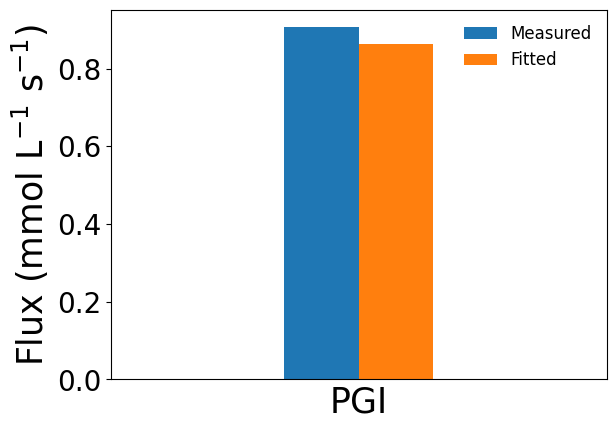

In [3]:
fit_res.plot_simulated_vs_measured_fluxes(
    out_dir=None, 
    reactions=['PGI'], 
    show_fig=True
)

## Generating model parameter sets
The calibrated reference flux distribution is then integrated with metabolomics, proteomics, and enzyme kinetic data to generate ensemble model parameter sets. This step is performed by sampling from the posterior distributions of metabolite concentrations, enzyme concentrations, and kinetic parameters.

The following example demonstrates this procedure.

In [4]:
METABOLOMICS = '../../models/e_coli/measured_metabolites.xlsx'
PROTEOMICS = '../../models/e_coli/measured_enzymes.xlsx'
KINETIC_PARAMETERS = '../../models/e_coli/measured_kinetic_parameters.xlsx'

metab_data = pd.read_excel(METABOLOMICS, header=0, index_col=0)
enz_data = pd.read_excel(PROTEOMICS, header=0, index_col=0)
kparam_data = pd.read_excel(KINETIC_PARAMETERS, header=0, index_col=0)

model.load_priors(
    'reference_fluxes',
    data=fit_res.estimated_fluxes,
    std=fit_res.estimated_flux_errors
)
model.load_priors(
    'metabolomics', 
    data=metab_data.iloc[:,0], 
    std=metab_data.iloc[:,1],
)
model.load_priors(
    'proteomics', 
    data=enz_data.iloc[:,0], 
    std=enz_data.iloc[:,1],
)
model.load_priors(
    'kparameters',
    data=kparam_data.iloc[:,0],
    std=kparam_data.iloc[:,1]
)
samp_res = model.generate_parameter_sets(
    alpha=None,
    n_tunes=5000,
    n_samples=2000,
    n_chains=10,
    n_jobs=10
)

<div class="alert alert-info">
<b>Note:</b> <br></br>
Metabolomics and proteomics data are expected in units of mM (cell volume-based). For kinetic parameters, catalytic constants have units of s$^{-1}$, Michaelis, activation, and inhibition constants have units of mM, and equilibrium constants are dimensionless.
</div>

During posterior sampling, the `alpha` argument defines a tunable coefficient that controls the tradeoff between consistency with experimental measurements and feasibility of the kinetic model.
- A smaller `alpha` keeps the posterior distributions closer to the original omics measurements and generally makes sampling easier, but the resulting kinetic model may be less balanced.
- A larger `alpha` enforces stronger consistency between the kinetic equations and the reference steady state, but may lead to more difficult sampling and reduced convergence efficiency.

By default, `alpha` is set to the geometric mean of the inverse variances of the reference fluxes.

`n_tunes` is directly passed to the [PyMC](https://www.pymc.io/welcome.html) samplers and controls the number of tuning (burn-in) iterations used to stabilize sampling before posterior samples are collected. The total number of posterior samples is determined by both the number of sampling chains specified by `n_chains` and the number of samples drawn per chain specified by `n_samples`.

After sampling is completed, all results are received by samp_res. In particular, sampled kinetic parameter sets can be accessed through the `sampled_kinetic_parameters` attribute.

In [5]:
samp_res.sampled_kinetic_parameters.sample(5)

,Ka_ACCOA_vPPC,Ka_FBP_vPPC,Ka_FBP_vPYK,Ka_PEP_vFBPase,Keq_vACK,Keq_vACON,Keq_vADK,Keq_vAKGDH,Keq_vALCD,Keq_vALDDH,...,kcat_vPTA,kcat_vPYK,kcat_vRPE,kcat_vRPI,kcat_vSDH,kcat_vSUCOAS,kcat_vTAL,kcat_vTKT1,kcat_vTKT2,kcat_vTPI
10973,1.870129,0.870527,1.747532,2.243964,337.527424,0.073662,0.699464,155582.867178,1192.781793,0.491528,...,21.905336,124.891760,2.109956,2064.644968,76.213010,2.473156,13.864075,2.043599,1.760774,8741.377981
7099,2.332932,1.868009,0.978254,2.331784,322.006271,0.033219,0.945926,123754.968077,1026.579617,0.190596,...,131.290824,138.561988,1.863342,273.485551,59.245313,1.070354,12.369193,0.937129,1.461572,7178.409988
6569,2.010493,1.770139,0.833338,2.076259,141.966629,0.115442,0.839103,362922.022172,1356.087648,0.127495,...,155.345317,134.760783,2.146779,2355.050995,132.490001,3.681403,15.224663,0.254971,2.363003,9332.960377
9233,2.198546,1.933340,1.249352,2.111623,229.801055,0.081238,1.003101,185048.884845,1572.620443,0.225697,...,31.319926,153.433054,1.755173,586.469550,86.098486,2.388448,13.255742,1.460273,1.749851,7113.498239
7963,2.387464,1.557875,3.141863,3.601756,261.003044,0.160908,1.022405,103608.127097,1432.528746,0.297042,...,113.045903,153.958044,2.227516,311.411164,58.020611,1.738744,11.246085,2.944525,2.777271,7547.605797


Comparisons between the prior distributions and sampled posterior distributions can be visualized using the provided plotting utility, illustrated here using the catalytic constant k$_{cat}^{GlcPTS}$, Michaelis constant K$_{m}^{PEP,PPC}$, and equilibrium constant K$_{eq}^{FBA}$:

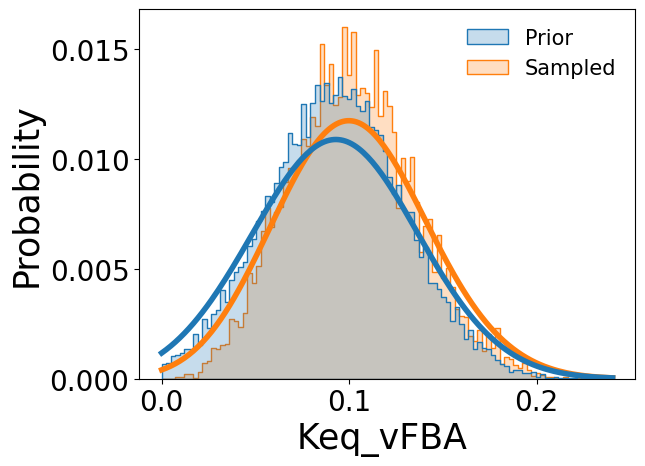

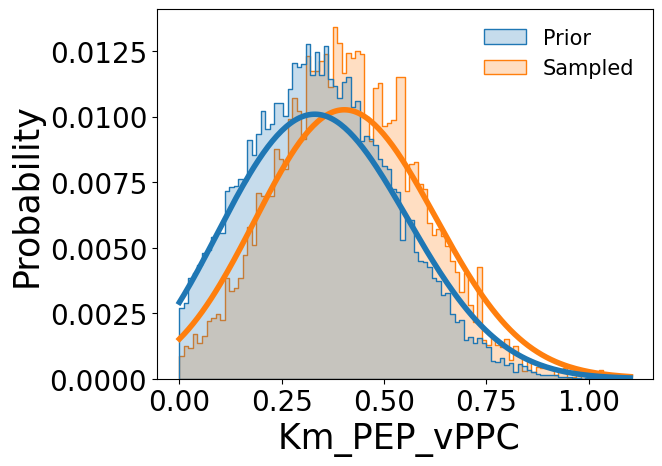

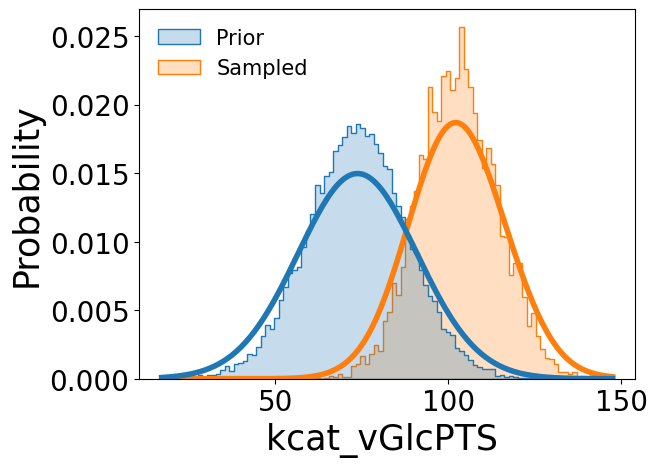

In [7]:
samp_res.plot_sampled_vs_prior_kinetic_parameters(
    out_dir=None, 
    parameters=['kcat_vGlcPTS', 'Km_PEP_vPPC', 'Keq_vFBA'], 
    show_fig=True
)

Similarly, sampled metabolite concentration sets can be accessed through

In [8]:
samp_res.sampled_metabolite_concentrations.sample(5)

,AC,ACALD,ACCOA,ACETP,ADP,AKG,AMP,ATP,BPG,CIT,...,PYR,Pi,R5P,Ru5P,S7P,SUC,SUCCOA,UQ,UQH2,Xu5P
9932,0.210686,0.181244,0.302144,0.186986,0.030406,0.052820,0.008098,0.479109,0.137904,0.147553,...,0.054040,0.147472,0.018113,0.045438,0.145702,0.172249,0.132912,0.147945,0.141645,0.097859
7854,0.216531,0.125369,0.312520,0.150798,0.052235,0.045836,0.005128,0.510380,0.184664,0.196658,...,0.056460,0.145168,0.024162,0.109934,0.170378,0.140536,0.174965,0.200266,0.139823,0.179706
15282,0.210595,0.108958,0.337574,0.139802,0.055148,0.059934,0.005603,0.496219,0.177995,0.100588,...,0.072680,0.157538,0.029852,0.024523,0.112865,0.213476,0.102343,0.084586,0.135467,0.219680
276,0.202213,0.180576,0.287823,0.096652,0.083652,0.063701,0.006530,0.476595,0.177534,0.114668,...,0.046049,0.091807,0.018890,0.113220,0.174743,0.144751,0.105163,0.112118,0.257921,0.093595
6274,0.195270,0.233839,0.314113,0.225211,0.042064,0.059626,0.006866,0.529823,0.074897,0.216247,...,0.144874,0.156079,0.015216,0.085632,0.076764,0.125076,0.185114,0.142033,0.195642,0.183659


and compared with the prior metabolomics data (using fructose 1,6-bisphosphate as an example).

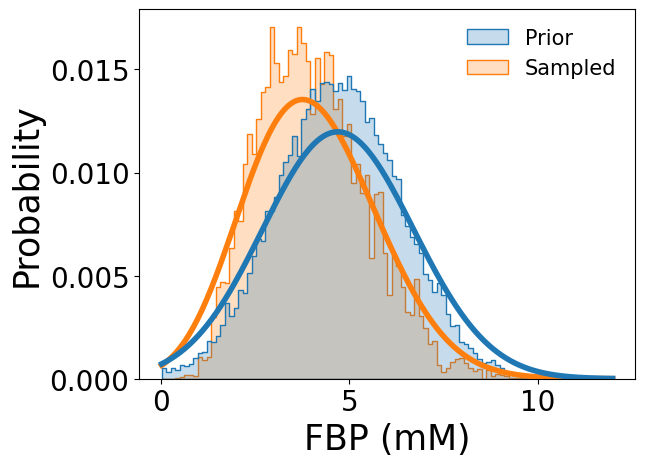

In [10]:
samp_res.plot_sampled_vs_prior_metabolites(
    out_dir=None, 
    metabolites=['FBP'], 
    show_fig=True
)

Sampled enzyme concentration sets are available through `sampled_enzyme_concentrations`, and comparisons with the prior proteomics data can be visualized (using pyruvate kinase as an example) as follows:

In [11]:
samp_res.sampled_enzyme_concentrations.sample(5)

,ACK,ACON,ADK,AKGDH,ALCD,ALDDH,ATPSyn,COX,CS,EDA,...,PPS,PTA,PYK,RPE,RPI,SDH,SUCOAS,TAL,TKT,TPI
1219,0.002922,0.038921,0.007545,0.009021,0.005966,0.006592,0.009701,0.001923,0.016836,0.008288,...,0.003619,0.003650,0.026954,0.007377,0.001651,0.004758,0.015840,0.019835,0.012376,0.005850
18685,0.003086,0.043500,0.008532,0.009250,0.006752,0.006218,0.009592,0.001733,0.016289,0.009758,...,0.003315,0.003463,0.023613,0.008305,0.001588,0.004434,0.014752,0.022703,0.013093,0.007637
15394,0.003669,0.050088,0.009360,0.008551,0.007302,0.006157,0.009723,0.002148,0.015850,0.009089,...,0.003443,0.003760,0.023940,0.008740,0.001465,0.003998,0.014591,0.022720,0.012212,0.007396
6000,0.003094,0.047729,0.008681,0.008357,0.008051,0.006331,0.009771,0.001866,0.017154,0.008673,...,0.003319,0.004492,0.025234,0.007138,0.001584,0.004128,0.015617,0.019959,0.013493,0.007629
9147,0.003227,0.045774,0.007356,0.009303,0.007498,0.006192,0.009635,0.001931,0.017013,0.008218,...,0.003567,0.003756,0.021409,0.008609,0.001349,0.004255,0.014663,0.015976,0.011786,0.006127


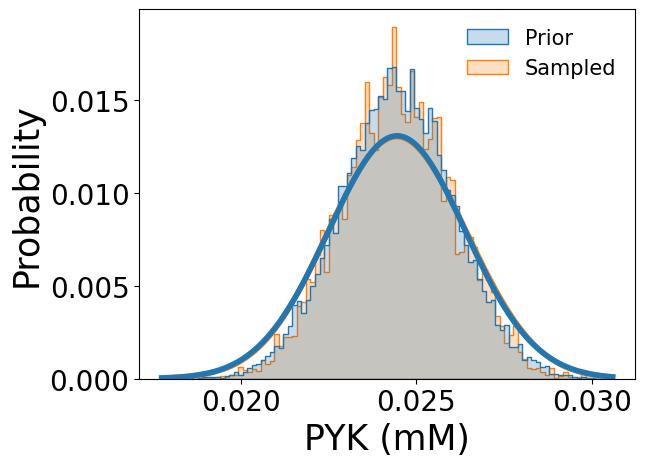

In [13]:
samp_res.plot_sampled_vs_prior_enzymes(
    out_dir=None, 
    enzymes=['PYK'], 
    show_fig=True
)

The full sampling trace is stored in samp_res.trace, which returns an `arviz.InferenceData` object. This enables direct compatibility with the analysis tool provided by ArviZ.